# Bayesian Linear Regression

## Real-World Scenario: Predicting Protein Abundance from Transcriptomics

In whole cell modeling, we want to predict **protein abundance** from mRNA expression levels. However, the relationship is noisy and we often have limited samples from expensive proteomics experiments. Unlike point estimates (OLS, ridge), **Bayesian linear regression** gives us a full posterior distribution over the weights $p(\mathbf{w} \mid \mathcal{D}, \sigma^2)$, which lets us:

- Quantify **uncertainty** in our predictions (crucial for guiding wet-lab experiments)
- See how the posterior **updates sequentially** as we collect more data
- Compute the **posterior predictive** distribution, capturing both observation noise and parameter uncertainty

This notebook implements the key ideas from PML Chapter 11.7:

- Gaussian prior on weights (Section 11.7.1)
- Posterior derivation via Bayes rule for Gaussians (Section 11.7.2)
- Sequential Bayesian updating (Section 11.7.3)
- Posterior predictive distribution (Section 11.7.4)
- The advantage of centering (Section 11.7.5)
- Dealing with multicollinearity (Section 11.7.6)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal, norm

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Key Formulas from PML Chapter 11.7

**Prior** (Eq. 11.118): We place a Gaussian prior on the weights:

$$p(\mathbf{w}) = \mathcal{N}(\mathbf{w} \mid \tilde{\mathbf{w}}, \tilde{\boldsymbol{\Sigma}})$$

**Likelihood** (Eq. 11.119): The data likelihood factorizes as:

$$p(\mathcal{D} \mid \mathbf{w}, \sigma^2) = \prod_{n=1}^{N} p(y_n \mid \mathbf{w}^\top \mathbf{x}_n, \sigma^2) = \mathcal{N}(\mathbf{y} \mid \mathbf{X}\mathbf{w}, \sigma^2 \mathbf{I}_N)$$

**Posterior** (Eq. 11.120–11.122): By Bayes rule for Gaussians:

$$p(\mathbf{w} \mid \mathbf{X}, \mathbf{y}, \sigma^2) = \mathcal{N}(\mathbf{w} \mid \hat{\mathbf{w}}, \hat{\boldsymbol{\Sigma}})$$

$$\hat{\mathbf{w}} = \hat{\boldsymbol{\Sigma}} \left( \tilde{\boldsymbol{\Sigma}}^{-1} \tilde{\mathbf{w}} + \frac{1}{\sigma^2} \mathbf{X}^\top \mathbf{y} \right)$$

$$\hat{\boldsymbol{\Sigma}} = \left( \tilde{\boldsymbol{\Sigma}}^{-1} + \frac{1}{\sigma^2} \mathbf{X}^\top \mathbf{X} \right)^{-1}$$

**Posterior predictive** (Eq. 11.123–11.124): At a test point $\mathbf{x}$:

$$p(y \mid \mathbf{x}, \mathcal{D}, \sigma^2) = \mathcal{N}\left(y \mid \hat{\boldsymbol{\mu}}^\top \mathbf{x},\ \hat{\sigma}^2(\mathbf{x})\right)$$

where $\hat{\sigma}^2(\mathbf{x}) = \sigma^2 + \mathbf{x}^\top \hat{\boldsymbol{\Sigma}}\, \mathbf{x}$

## 1. Generate Synthetic Proteomics Data

We simulate a simple 1D model: protein abundance depends linearly on mRNA expression plus Gaussian noise. This matches the setting in Section 11.7.3 where we can visualize the 2D posterior over $(w_0, w_1)$.

In [2]:
# True model: protein = w0 + w1 * mRNA + noise
w0_true, w1_true = -0.3, 0.5
sigma_true = 0.5  # observation noise (known)

# Generate training data (mRNA expression levels, standardized)
N_total = 100
x_train = np.random.uniform(-1, 1, N_total)
y_train = w0_true + w1_true * x_train + np.random.randn(N_total) * sigma_true

# Design matrix with intercept column: X = [1, x]
def make_design(x):
    return np.column_stack([np.ones_like(x), x])

X_train = make_design(x_train)

print(f"True parameters: w₀ = {w0_true}, w₁ = {w1_true}")
print(f"Observation noise: σ = {sigma_true}")
print(f"Total data points: {N_total}")
print(f"Design matrix shape: {X_train.shape}")

True parameters: w₀ = -0.3, w₁ = 0.5
Observation noise: σ = 0.5
Total data points: 100
Design matrix shape: (100, 2)


## 2. Bayesian Posterior (Section 11.7.1–11.7.2)

We implement the posterior computation using Bayes rule for Gaussians. With a prior $p(\mathbf{w}) = \mathcal{N}(\tilde{\mathbf{w}}, \tilde{\boldsymbol{\Sigma}})$ and likelihood $p(\mathbf{y} \mid \mathbf{X}, \mathbf{w}) = \mathcal{N}(\mathbf{X}\mathbf{w}, \sigma^2\mathbf{I})$, the posterior is:

$$\hat{\boldsymbol{\Sigma}} = \left(\tilde{\boldsymbol{\Sigma}}^{-1} + \frac{1}{\sigma^2}\mathbf{X}^\top\mathbf{X}\right)^{-1}, \quad \hat{\mathbf{w}} = \hat{\boldsymbol{\Sigma}}\left(\tilde{\boldsymbol{\Sigma}}^{-1}\tilde{\mathbf{w}} + \frac{1}{\sigma^2}\mathbf{X}^\top\mathbf{y}\right)$$

With $\tilde{\mathbf{w}} = \mathbf{0}$ and $\tilde{\boldsymbol{\Sigma}} = \tau^2\mathbf{I}$, setting $\lambda = \sigma^2/\tau^2$ recovers the ridge estimate.

In [3]:
def bayesian_linreg_posterior(X, y, sigma2, prior_mean, prior_cov):
    """Compute the Bayesian linear regression posterior (Eq. 11.120-11.122)."""
    prior_prec = np.linalg.inv(prior_cov)
    post_prec = prior_prec + (1.0 / sigma2) * X.T @ X
    post_cov = np.linalg.inv(post_prec)
    post_mean = post_cov @ (prior_prec @ prior_mean + (1.0 / sigma2) * X.T @ y)
    return post_mean, post_cov

# Vague prior: w ~ N(0, tau^2 * I) with large tau^2
tau2 = 2.0
D = 2  # w0, w1
prior_mean = np.zeros(D)
prior_cov = tau2 * np.eye(D)

# Compute posterior using ALL data
sigma2 = sigma_true**2
post_mean, post_cov = bayesian_linreg_posterior(X_train, y_train, sigma2, prior_mean, prior_cov)

print("Prior:")
print(f"  w̃ = {prior_mean}")
print(f"  Σ̃ = diag({tau2}, {tau2})")
print(f"\nPosterior (N = {N_total}):")
print(f"  ŵ = [{post_mean[0]:.4f}, {post_mean[1]:.4f}]")
print(f"  True = [{w0_true}, {w1_true}]")
print(f"\nPosterior std: [{np.sqrt(post_cov[0,0]):.4f}, {np.sqrt(post_cov[1,1]):.4f}]")
print(f"Posterior correlation: {post_cov[0,1] / np.sqrt(post_cov[0,0]*post_cov[1,1]):.4f}")

# Connection to ridge: lambda = sigma^2 / tau^2
lam = sigma2 / tau2
w_ridge = np.linalg.solve(X_train.T @ X_train + lam * np.eye(D), X_train.T @ y_train)
print(f"\nRidge estimate (λ = σ²/τ² = {lam:.2f}): [{w_ridge[0]:.4f}, {w_ridge[1]:.4f}]")
print(f"Posterior mean = Ridge MAP estimate: {np.allclose(post_mean, w_ridge)}")

Prior:
  w̃ = [0. 0.]
  Σ̃ = diag(2.0, 2.0)

Posterior (N = 100):
  ŵ = [-0.3071, 0.3838]
  True = [-0.3, 0.5]

Posterior std: [0.0502, 0.0843]
Posterior correlation: 0.1000

Ridge estimate (λ = σ²/τ² = 0.12): [-0.3071, 0.3838]
Posterior mean = Ridge MAP estimate: True


## 3. Sequential Bayesian Updating (Section 11.7.3)

A key property of the Bayesian approach: we can update our beliefs **one data point at a time**. After seeing $N$ points, the posterior becomes the prior for point $N+1$. This is equivalent to computing the posterior using all $N$ points at once.

We reproduce Figure 11.20: the likelihood, posterior, and posterior predictive distribution evolve as we see $N = 0, 1, 2, 100$ data points.

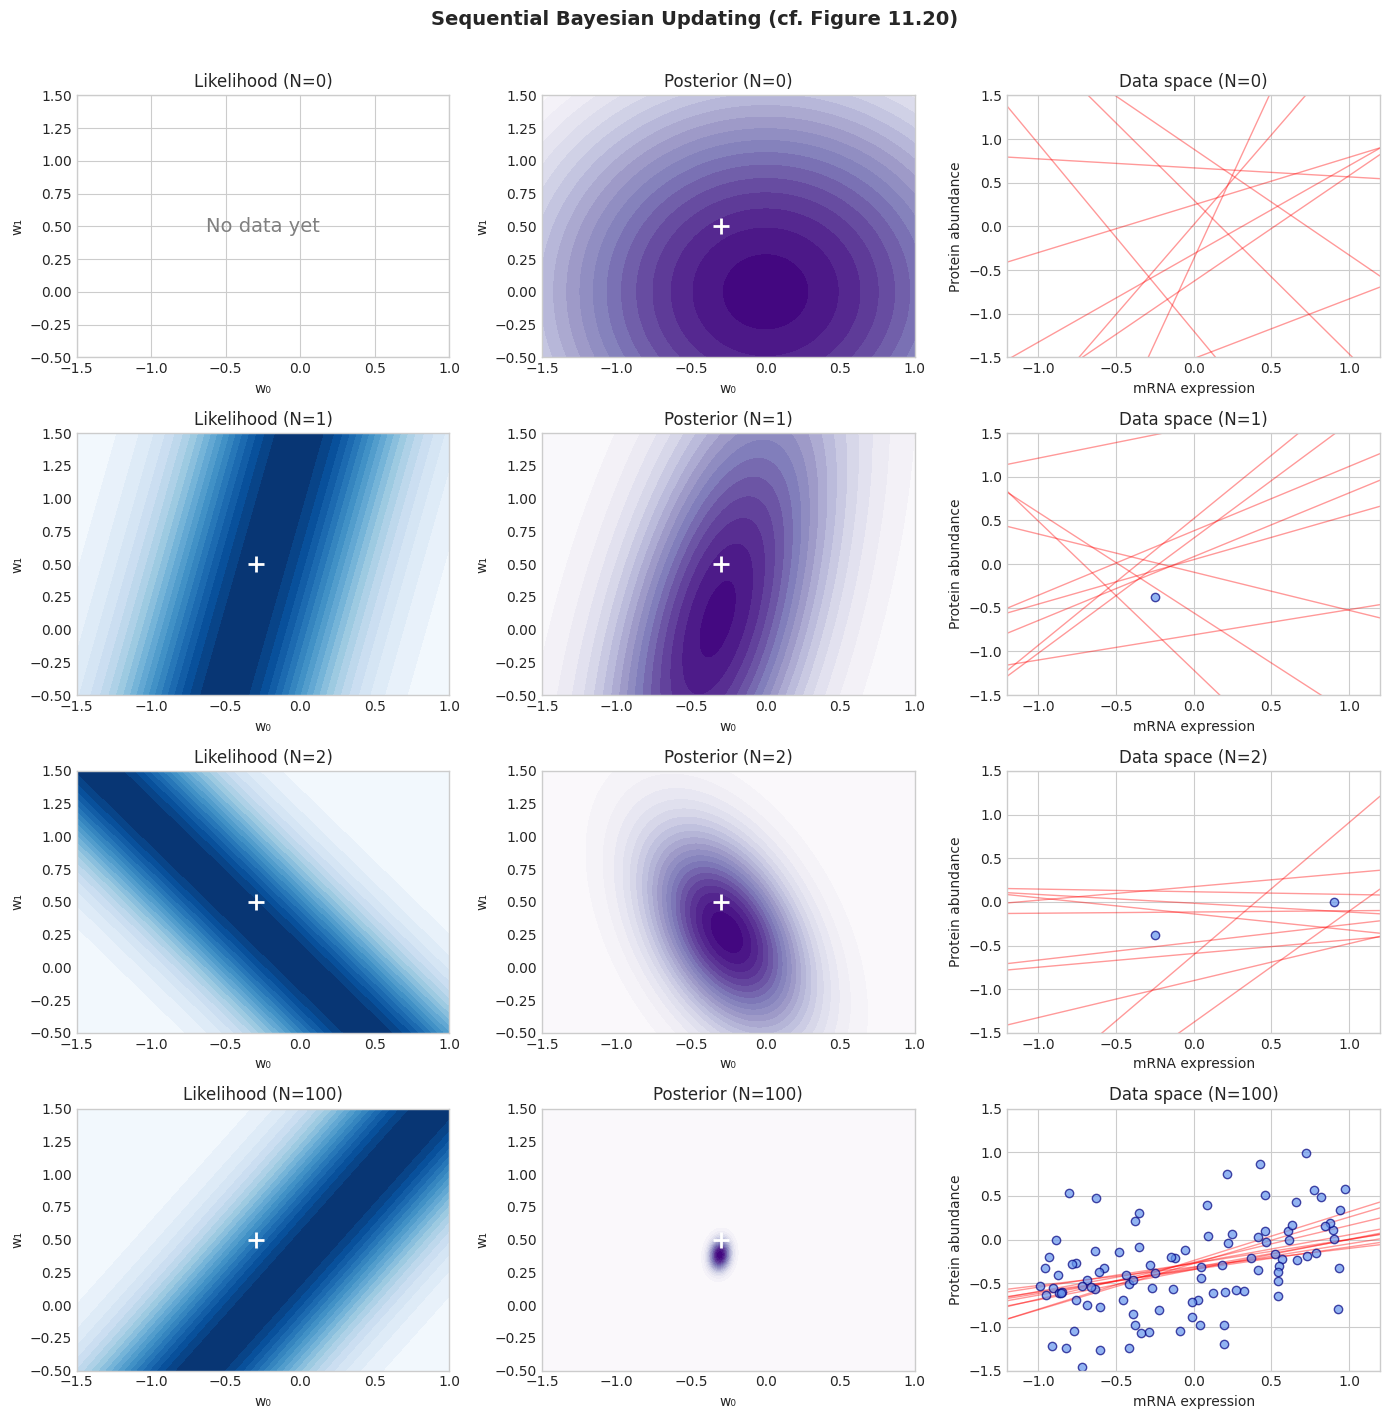

In [4]:
# Sequential updating for N = 0, 1, 2, 100
N_stages = [0, 1, 2, N_total]

# Grid for plotting the 2D parameter space
w0_grid = np.linspace(-1.5, 1.0, 200)
w1_grid = np.linspace(-0.5, 1.5, 200)
W0, W1 = np.meshgrid(w0_grid, w1_grid)
pos = np.dstack((W0, W1))

# x range for data space predictions
x_pred = np.linspace(-1.2, 1.2, 200)
X_pred = make_design(x_pred)

fig, axes = plt.subplots(len(N_stages), 3, figsize=(14, 3.5 * len(N_stages)))

for row, N in enumerate(N_stages):
    # Compute posterior after seeing N data points
    if N == 0:
        curr_mean, curr_cov = prior_mean.copy(), prior_cov.copy()
    else:
        X_N = X_train[:N]
        y_N = y_train[:N]
        curr_mean, curr_cov = bayesian_linreg_posterior(
            X_N, y_N, sigma2, prior_mean, prior_cov
        )

    # --- Column 1: Likelihood for current data point ---
    ax = axes[row, 0]
    if N == 0:
        ax.text(0.5, 0.5, 'No data yet', transform=ax.transAxes,
                ha='center', va='center', fontsize=14, color='gray')
        ax.set_xlim(w0_grid[0], w0_grid[-1])
        ax.set_ylim(w1_grid[0], w1_grid[-1])
    else:
        # Likelihood for the N-th data point: p(y_N | w) = N(y_N | x_N^T w, sigma^2)
        xn = X_train[N-1]
        yn = y_train[N-1]
        # For each (w0, w1), compute log-likelihood
        pred = W0 * xn[0] + W1 * xn[1]  # x_n^T w
        ll = -0.5 * (yn - pred)**2 / sigma2
        ll_density = np.exp(ll - ll.max())
        ax.contourf(W0, W1, ll_density, levels=20, cmap='Blues')
        ax.plot(w0_true, w1_true, 'w+', markersize=12, markeredgewidth=2)
    ax.set_xlabel('w₀')
    ax.set_ylabel('w₁')
    ax.set_title(f'Likelihood (N={N})')

    # --- Column 2: Posterior ---
    ax = axes[row, 1]
    rv = multivariate_normal(curr_mean, curr_cov)
    pdf = rv.pdf(pos)
    ax.contourf(W0, W1, pdf, levels=20, cmap='Purples')
    ax.plot(w0_true, w1_true, 'w+', markersize=12, markeredgewidth=2)
    ax.set_xlabel('w₀')
    ax.set_ylabel('w₁')
    ax.set_title(f'Posterior (N={N})')

    # --- Column 3: Data space (posterior predictive samples) ---
    ax = axes[row, 2]
    # Draw samples from the posterior and plot corresponding lines
    n_samples = 10
    w_samples = np.random.multivariate_normal(curr_mean, curr_cov, n_samples)
    for ws in w_samples:
        y_line = X_pred @ ws
        ax.plot(x_pred, y_line, 'r-', alpha=0.4, linewidth=1)
    # Plot observed data
    if N > 0:
        ax.plot(x_train[:N], y_train[:N], 'bo', markersize=6, alpha=0.7,
                markeredgecolor='navy', markerfacecolor='cornflowerblue')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel('mRNA expression')
    ax.set_ylabel('Protein abundance')
    ax.set_title(f'Data space (N={N})')

fig.suptitle('Sequential Bayesian Updating (cf. Figure 11.20)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:**
- **Row 1 (N=0):** The posterior equals the prior — predictions are "all over the place"
- **Row 2 (N=1):** One data point constrains the posterior to a ridge shape (many slope/intercept combinations pass through one point)
- **Row 3 (N=2):** Two points pin down the line much better — the posterior concentrates
- **Row 4 (N=100):** The posterior is essentially a delta function centered on the true parameters $(w_0, w_1) = (-0.3, 0.5)$

## 4. Posterior Predictive Distribution (Section 11.7.4)

The posterior predictive integrates out parameter uncertainty (Eq. 11.123–11.124):

$$p(y \mid \mathbf{x}, \mathcal{D}, \sigma^2) = \int \mathcal{N}(y \mid \mathbf{x}^\top\mathbf{w}, \sigma^2)\,\mathcal{N}(\mathbf{w} \mid \hat{\boldsymbol{\mu}}, \hat{\boldsymbol{\Sigma}})\,d\mathbf{w} = \mathcal{N}\left(y \mid \hat{\boldsymbol{\mu}}^\top\mathbf{x},\ \hat{\sigma}^2(\mathbf{x})\right)$$

where $\hat{\sigma}^2(\mathbf{x}) = \sigma^2 + \mathbf{x}^\top \hat{\boldsymbol{\Sigma}}\,\mathbf{x}$. The predicted variance has **two components**:
- $\sigma^2$: irreducible observation noise
- $\mathbf{x}^\top \hat{\boldsymbol{\Sigma}}\,\mathbf{x}$: parameter uncertainty (grows away from training data)

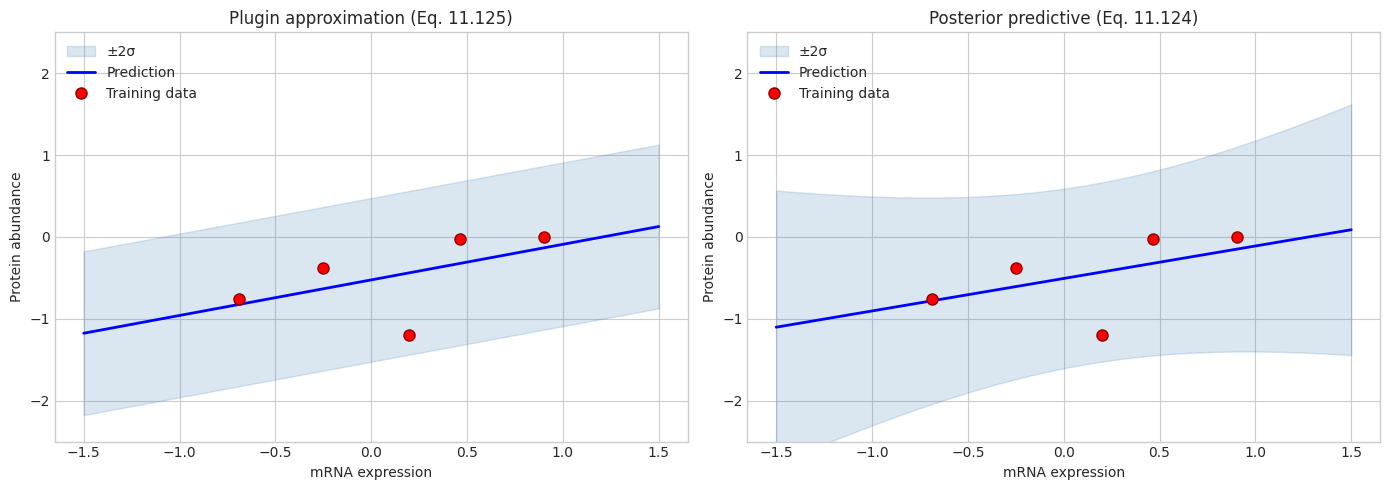

Plugin: constant error bars (only observation noise σ²)
Bayesian: error bars grow away from data (σ² + x'Σ̂x)


In [5]:
def posterior_predictive(X_test, post_mean, post_cov, sigma2):
    """Compute posterior predictive mean and variance (Eq. 11.124)."""
    pred_mean = X_test @ post_mean
    # Variance: sigma^2 + x^T Sigma_post x  for each test point
    pred_var = sigma2 + np.sum(X_test @ post_cov * X_test, axis=1)
    return pred_mean, pred_var

# Plugin approximation (just use point estimate, no parameter uncertainty)
def plugin_predictive(X_test, w_hat, sigma2):
    pred_mean = X_test @ w_hat
    pred_var = sigma2 * np.ones(len(X_test))
    return pred_mean, pred_var

# Use N=5 data points for visible uncertainty
N_demo = 5
X_demo = X_train[:N_demo]
y_demo = y_train[:N_demo]
post_mean_demo, post_cov_demo = bayesian_linreg_posterior(
    X_demo, y_demo, sigma2, prior_mean, prior_cov
)

# OLS estimate for plugin
w_ols = np.linalg.lstsq(X_demo, y_demo, rcond=None)[0]

x_dense = np.linspace(-1.5, 1.5, 300)
X_dense = make_design(x_dense)

# Posterior predictive
pred_mean_bayes, pred_var_bayes = posterior_predictive(
    X_dense, post_mean_demo, post_cov_demo, sigma2
)
pred_std_bayes = np.sqrt(pred_var_bayes)

# Plugin predictive
pred_mean_plugin, pred_var_plugin = plugin_predictive(X_dense, w_ols, sigma2)
pred_std_plugin = np.sqrt(pred_var_plugin)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, title, pmean, pstd in [
    (axes[0], 'Plugin approximation (Eq. 11.125)', pred_mean_plugin, pred_std_plugin),
    (axes[1], 'Posterior predictive (Eq. 11.124)', pred_mean_bayes, pred_std_bayes)
]:
    ax.fill_between(x_dense, pmean - 2*pstd, pmean + 2*pstd,
                    alpha=0.2, color='steelblue', label='±2σ')
    ax.plot(x_dense, pmean, 'b-', linewidth=2, label='Prediction')
    ax.plot(x_train[:N_demo], y_train[:N_demo], 'ro', markersize=8,
            markeredgecolor='darkred', label='Training data')
    ax.set_xlabel('mRNA expression')
    ax.set_ylabel('Protein abundance')
    ax.set_title(title)
    ax.set_ylim(-2.5, 2.5)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

print("Plugin: constant error bars (only observation noise σ²)")
print("Bayesian: error bars grow away from data (σ² + x'Σ̂x)")

## 5. Plugin vs Posterior Samples (cf. Figure 11.21)

The plugin approximation (Eq. 11.125) replaces the posterior with a delta function at $\hat{\mathbf{w}}$, giving constant variance. The full Bayesian approach samples from the true posterior, producing a *range* of plausible functions.

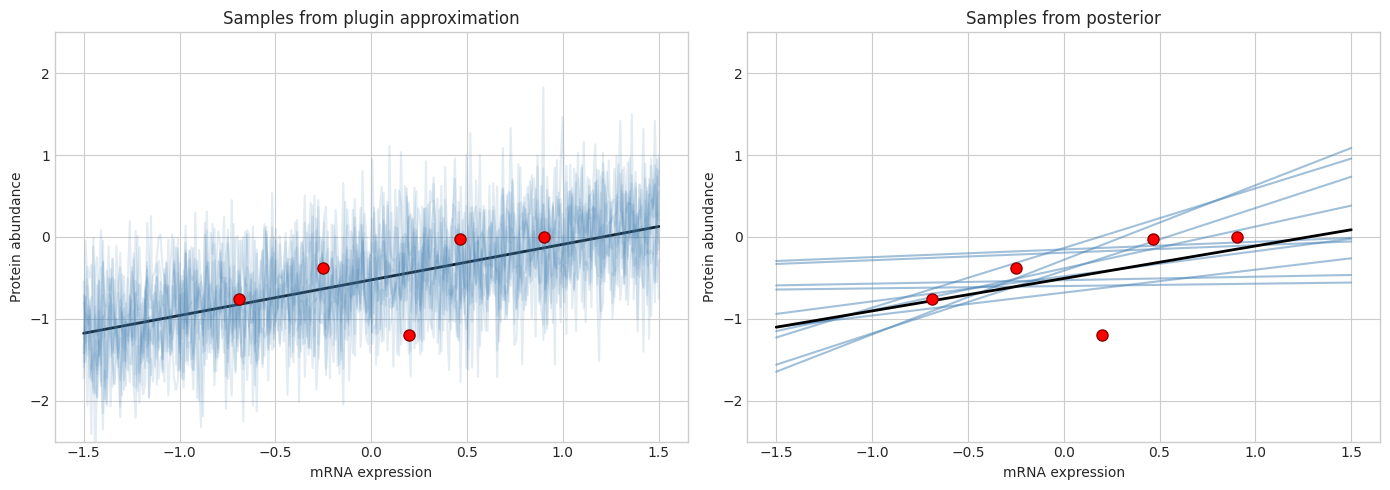

Plugin: all sampled functions have the same slope/intercept
Posterior: sampled functions show genuine uncertainty in the parameters


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Samples from plugin (just one line, since delta posterior)
ax = axes[0]
ax.plot(x_dense, X_dense @ w_ols, 'k-', linewidth=2, label='OLS fit')
for _ in range(10):
    y_sample = X_dense @ w_ols + np.random.randn(len(x_dense)) * sigma_true
    ax.plot(x_dense, y_sample, '-', alpha=0.15, color='steelblue')
ax.plot(x_train[:N_demo], y_train[:N_demo], 'ro', markersize=8, markeredgecolor='darkred')
ax.set_xlabel('mRNA expression')
ax.set_ylabel('Protein abundance')
ax.set_title('Samples from plugin approximation')
ax.set_ylim(-2.5, 2.5)

# (b) Samples from true posterior
ax = axes[1]
w_samples = np.random.multivariate_normal(post_mean_demo, post_cov_demo, 10)
for ws in w_samples:
    y_line = X_dense @ ws
    ax.plot(x_dense, y_line, '-', alpha=0.5, color='steelblue', linewidth=1.5)
ax.plot(x_dense, X_dense @ post_mean_demo, 'k-', linewidth=2, label='Posterior mean')
ax.plot(x_train[:N_demo], y_train[:N_demo], 'ro', markersize=8, markeredgecolor='darkred')
ax.set_xlabel('mRNA expression')
ax.set_ylabel('Protein abundance')
ax.set_title('Samples from posterior')
ax.set_ylim(-2.5, 2.5)

plt.tight_layout()
plt.show()

print("Plugin: all sampled functions have the same slope/intercept")
print("Posterior: sampled functions show genuine uncertainty in the parameters")

## 6. The Advantage of Centering (Section 11.7.5)

The 2D posterior in Figure 11.20 is an elongated ellipse — there is strong **correlation** between $w_0$ and $w_1$. This is because many lines with different slopes/intercepts pass through the mean of the data $(\bar{x}, \bar{y})$: if we increase the slope, we must decrease the intercept.

**Fix:** Center the inputs $x'_n = x_n - \bar{x}$. Now the lines pivot around the origin, reducing posterior correlation.

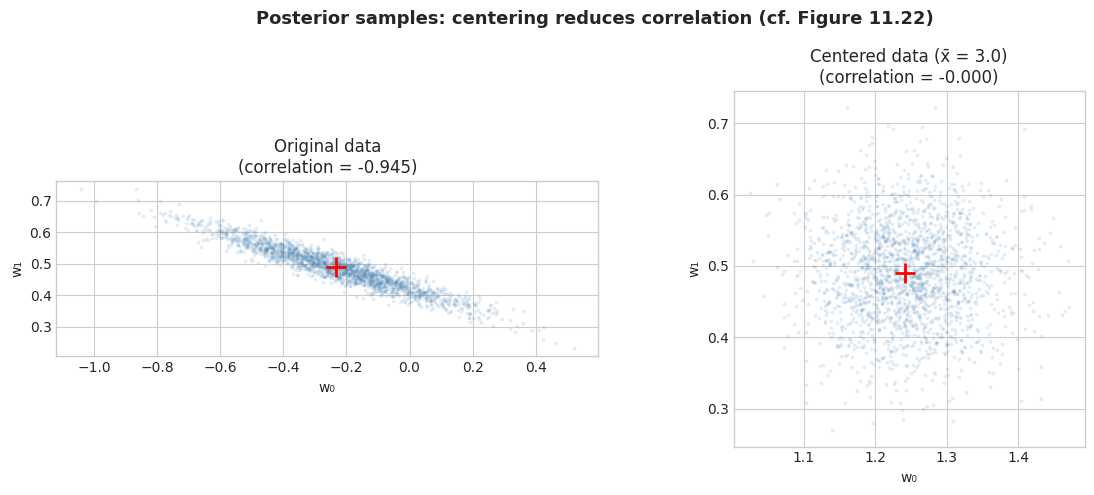


Original posterior mean:  w₀ = -0.2344, w₁ = 0.4890
Centered → recovered:    w₀ = -0.2431, w₁ = 0.4906
(Using Eq. 11.126: w₀ = w₀' - w₁'x̄,  w₁ = w₁')


In [7]:
# Use non-centered data (x not symmetric around 0) to make the effect visible
np.random.seed(7)
x_offset = np.random.uniform(1, 5, 50)  # data centered around ~3, not 0
y_offset = w0_true + w1_true * x_offset + np.random.randn(50) * sigma_true

# (a) Original (uncentered) data
X_orig = make_design(x_offset)
post_mean_orig, post_cov_orig = bayesian_linreg_posterior(
    X_orig, y_offset, sigma2, prior_mean, prior_cov
)

# (b) Centered data
x_bar = np.mean(x_offset)
x_centered = x_offset - x_bar
X_cent = make_design(x_centered)
post_mean_cent, post_cov_cent = bayesian_linreg_posterior(
    X_cent, y_offset, sigma2, prior_mean, prior_cov
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Draw posterior samples and plot in w0-w1 space
for ax, pm, pc, title in [
    (axes[0], post_mean_orig, post_cov_orig, 'Original data'),
    (axes[1], post_mean_cent, post_cov_cent, f'Centered data (x̄ = {x_bar:.1f})')
]:
    samples = np.random.multivariate_normal(pm, pc, 2000)
    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.1, s=3, color='steelblue')
    ax.plot(pm[0], pm[1], 'r+', markersize=15, markeredgewidth=2)
    corr = pc[0,1] / np.sqrt(pc[0,0] * pc[1,1])
    ax.set_xlabel('w₀')
    ax.set_ylabel('w₁')
    ax.set_title(f'{title}\n(correlation = {corr:.3f})')
    ax.set_aspect('equal')

fig.suptitle('Posterior samples: centering reduces correlation (cf. Figure 11.22)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Convert centered parameters back to original coordinates (Eq. 11.126)
w0_recovered = post_mean_cent[0] - post_mean_cent[1] * x_bar
w1_recovered = post_mean_cent[1]
print(f"\nOriginal posterior mean:  w₀ = {post_mean_orig[0]:.4f}, w₁ = {post_mean_orig[1]:.4f}")
print(f"Centered → recovered:    w₀ = {w0_recovered:.4f}, w₁ = {w1_recovered:.4f}")
print(f"(Using Eq. 11.126: w₀ = w₀' - w₁'x̄,  w₁ = w₁')")

## 7. Multicollinearity (Section 11.7.6)

When features are highly correlated, individual coefficients become **non-identifiable**: we can't tell which feature matters, only that their combination predicts the target. However, the *sum* of correlated coefficients is well-determined.

We reproduce the "left leg / right leg" example: predicting a person's height from correlated leg measurements.

In [8]:
# Multi-leg example (adapted from Section 11.7.6)
# Predict height from left and right leg length (which are ~identical)
np.random.seed(123)
N_legs = 100
h_bar = 10.0  # mean height
heights = np.random.normal(h_bar, 2, N_legs)

# Legs are ~40-50% of height, plus noise
rho = np.random.uniform(0.4, 0.5, N_legs)  # fraction
left_legs = np.random.normal(rho * heights, np.sqrt(0.02))
right_legs = np.random.normal(rho * heights, np.sqrt(0.02))

# Correlation between left and right legs
leg_corr = np.corrcoef(left_legs, right_legs)[0, 1]

# Bayesian regression: h ~ N(alpha + beta_l * l + beta_r * r, sigma^2)
X_legs = np.column_stack([np.ones(N_legs), left_legs, right_legs])
sigma_legs = 1.0

prior_mean_legs = np.zeros(3)
prior_cov_legs = 100.0 * np.eye(3)  # vague prior

post_mean_legs, post_cov_legs = bayesian_linreg_posterior(
    X_legs, heights, sigma_legs**2, prior_mean_legs, prior_cov_legs
)

print(f"Leg correlation: {leg_corr:.3f}")
print(f"\nExpected each β ≈ h̄/l̄ ≈ {h_bar / (0.45 * h_bar):.1f}")
print(f"\nPosterior means:")
print(f"  α  (intercept)  = {post_mean_legs[0]:.3f} ± {np.sqrt(post_cov_legs[0,0]):.3f}")
print(f"  β_l (left leg)  = {post_mean_legs[1]:.3f} ± {np.sqrt(post_cov_legs[1,1]):.3f}")
print(f"  β_r (right leg) = {post_mean_legs[2]:.3f} ± {np.sqrt(post_cov_legs[2,2]):.3f}")
print(f"\n  β_l + β_r       = {post_mean_legs[1] + post_mean_legs[2]:.3f}")
print("\n→ Individual β's are uncertain, but their sum is well-determined!")

Leg correlation: 0.985

Expected each β ≈ h̄/l̄ ≈ 2.2

Posterior means:
  α  (intercept)  = 0.651 ± 0.448
  β_l (left leg)  = 1.173 ± 0.557
  β_r (right leg) = 0.913 ± 0.554

  β_l + β_r       = 2.086

→ Individual β's are uncertain, but their sum is well-determined!


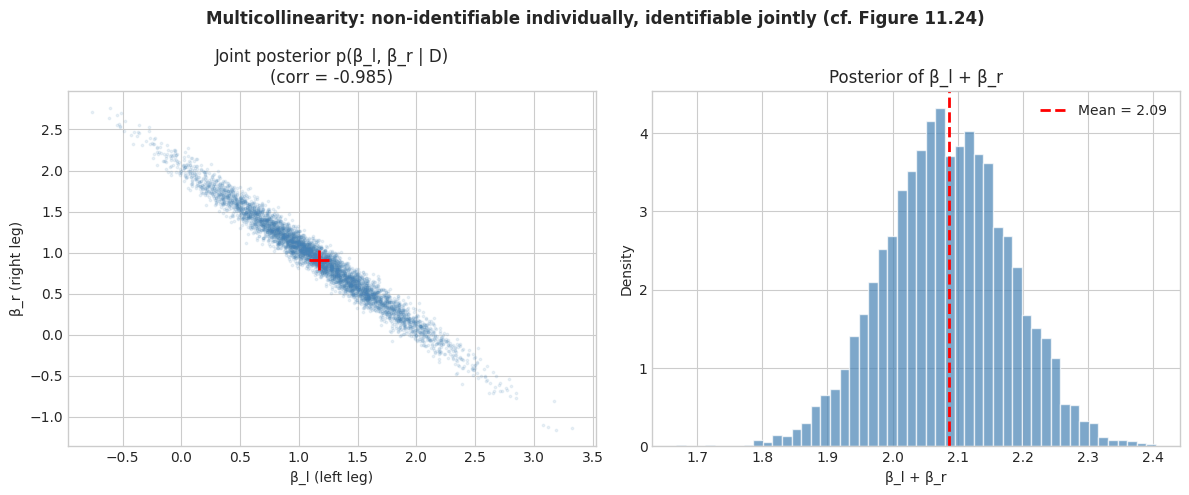

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Joint posterior p(beta_l, beta_r | D) — showing the anti-correlation
ax = axes[0]
samples_legs = np.random.multivariate_normal(post_mean_legs, post_cov_legs, 5000)
ax.scatter(samples_legs[:, 1], samples_legs[:, 2], alpha=0.1, s=3, color='steelblue')
ax.plot(post_mean_legs[1], post_mean_legs[2], 'r+', markersize=15, markeredgewidth=2)
ax.set_xlabel('β_l (left leg)')
ax.set_ylabel('β_r (right leg)')
corr_lr = post_cov_legs[1,2] / np.sqrt(post_cov_legs[1,1] * post_cov_legs[2,2])
ax.set_title(f'Joint posterior p(β_l, β_r | D)\n(corr = {corr_lr:.3f})')

# (b) Posterior of beta_l + beta_r — well-determined
ax = axes[1]
beta_sum = samples_legs[:, 1] + samples_legs[:, 2]
ax.hist(beta_sum, bins=50, density=True, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(post_mean_legs[1] + post_mean_legs[2], color='red', linewidth=2,
           linestyle='--', label=f'Mean = {post_mean_legs[1] + post_mean_legs[2]:.2f}')
ax.set_xlabel('β_l + β_r')
ax.set_ylabel('Density')
ax.set_title('Posterior of β_l + β_r')
ax.legend()

fig.suptitle('Multicollinearity: non-identifiable individually, identifiable jointly (cf. Figure 11.24)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Posterior Uncertainty Decreases with Data

As $N$ increases, the posterior variance $\hat{\boldsymbol{\Sigma}}$ shrinks and the posterior mean converges to the true weights. This demonstrates the **consistency** of the Bayesian estimator.

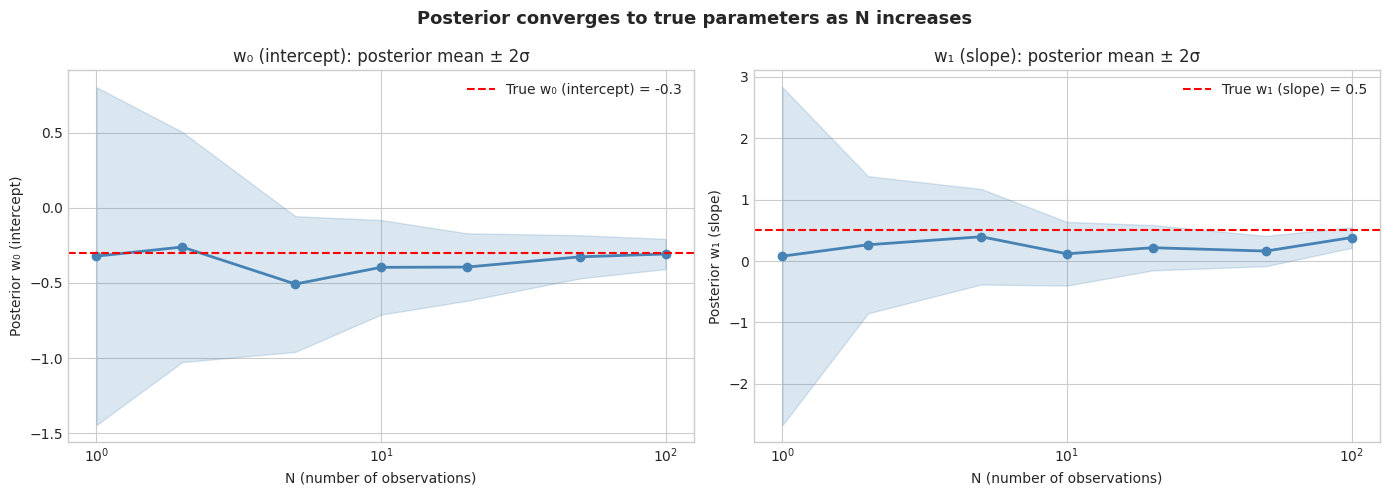

In [10]:
N_values = [1, 2, 5, 10, 20, 50, 100]
post_means_w0 = []
post_means_w1 = []
post_stds_w0 = []
post_stds_w1 = []

for N in N_values:
    pm, pc = bayesian_linreg_posterior(
        X_train[:N], y_train[:N], sigma2, prior_mean, prior_cov
    )
    post_means_w0.append(pm[0])
    post_means_w1.append(pm[1])
    post_stds_w0.append(np.sqrt(pc[0, 0]))
    post_stds_w1.append(np.sqrt(pc[1, 1]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, means, stds, true_val, name in [
    (axes[0], post_means_w0, post_stds_w0, w0_true, 'w₀ (intercept)'),
    (axes[1], post_means_w1, post_stds_w1, w1_true, 'w₁ (slope)')
]:
    means = np.array(means)
    stds = np.array(stds)
    ax.fill_between(N_values, means - 2*stds, means + 2*stds,
                    alpha=0.2, color='steelblue')
    ax.plot(N_values, means, 'o-', color='steelblue', linewidth=2, markersize=6)
    ax.axhline(true_val, color='red', linestyle='--', linewidth=1.5,
               label=f'True {name} = {true_val}')
    ax.set_xlabel('N (number of observations)')
    ax.set_ylabel(f'Posterior {name}')
    ax.set_title(f'{name}: posterior mean ± 2σ')
    ax.legend()
    ax.set_xscale('log')

plt.suptitle('Posterior converges to true parameters as N increases',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Higher-Dimensional Example: Whole Cell Protein Prediction

We apply Bayesian linear regression to a more realistic setting: predicting protein levels from a panel of mRNA features. With $D > 2$, we can't visualize the full posterior, but we can examine **marginal posteriors** and **posterior predictive** uncertainty.

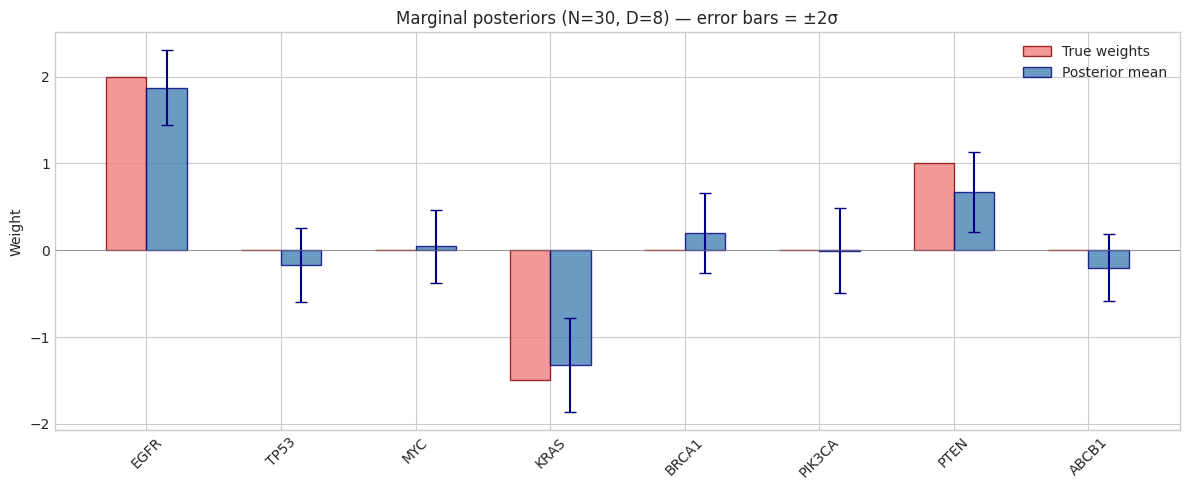

The Bayesian posterior correctly identifies EGFR, KRAS, and PTEN
as the relevant genes, while showing high uncertainty for irrelevant ones.


In [11]:
# Multi-gene protein prediction
np.random.seed(42)
D_multi = 8
N_multi = 30  # limited proteomics samples
sigma_multi = 1.0

gene_names_multi = ['EGFR', 'TP53', 'MYC', 'KRAS', 'BRCA1', 'PIK3CA', 'PTEN', 'ABCB1']

# True weights: only 3 genes matter
w_true_multi = np.zeros(D_multi)
w_true_multi[0] = 2.0   # EGFR
w_true_multi[3] = -1.5  # KRAS
w_true_multi[6] = 1.0   # PTEN

# Correlated gene expression (some genes co-express)
cov_genes = np.eye(D_multi)
cov_genes[0, 3] = cov_genes[3, 0] = 0.5  # EGFR-KRAS pathway
cov_genes[4, 6] = cov_genes[6, 4] = 0.4  # BRCA1-PTEN
L = np.linalg.cholesky(cov_genes)

X_multi = (L @ np.random.randn(D_multi, N_multi)).T
y_multi = X_multi @ w_true_multi + np.random.randn(N_multi) * sigma_multi

# Prior
prior_mean_multi = np.zeros(D_multi)
prior_cov_multi = 5.0 * np.eye(D_multi)

post_mean_multi, post_cov_multi = bayesian_linreg_posterior(
    X_multi, y_multi, sigma_multi**2, prior_mean_multi, prior_cov_multi
)

# Marginal posteriors
fig, ax = plt.subplots(figsize=(12, 5))

x_pos = np.arange(D_multi)
post_stds_multi = np.sqrt(np.diag(post_cov_multi))

ax.bar(x_pos - 0.15, w_true_multi, 0.3, label='True weights', color='lightcoral',
       edgecolor='darkred', alpha=0.8)
ax.bar(x_pos + 0.15, post_mean_multi, 0.3, label='Posterior mean', color='steelblue',
       edgecolor='navy', alpha=0.8)
ax.errorbar(x_pos + 0.15, post_mean_multi, yerr=2*post_stds_multi,
            fmt='none', ecolor='navy', capsize=4, linewidth=1.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(gene_names_multi, rotation=45)
ax.set_ylabel('Weight')
ax.set_title(f'Marginal posteriors (N={N_multi}, D={D_multi}) — error bars = ±2σ')
ax.legend()
ax.axhline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

print("The Bayesian posterior correctly identifies EGFR, KRAS, and PTEN")
print("as the relevant genes, while showing high uncertainty for irrelevant ones.")

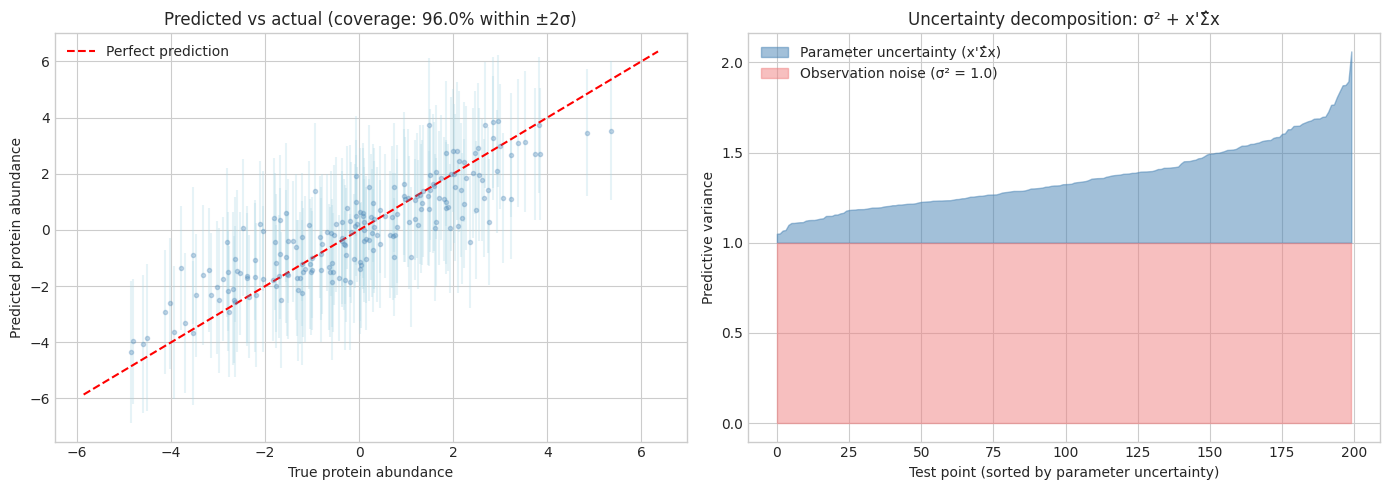

In [12]:
# Posterior predictive on test data
N_test_multi = 200
X_test_multi = (L @ np.random.randn(D_multi, N_test_multi)).T
y_test_multi = X_test_multi @ w_true_multi + np.random.randn(N_test_multi) * sigma_multi

pred_mean_multi, pred_var_multi = posterior_predictive(
    X_test_multi, post_mean_multi, post_cov_multi, sigma_multi**2
)
pred_std_multi = np.sqrt(pred_var_multi)

# Check calibration: what fraction of true values fall within ±2σ?
in_interval = np.abs(y_test_multi - pred_mean_multi) < 2 * pred_std_multi
coverage = np.mean(in_interval)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Predicted vs actual
ax = axes[0]
ax.errorbar(y_test_multi, pred_mean_multi, yerr=2*pred_std_multi,
            fmt='o', alpha=0.3, markersize=3, color='steelblue', ecolor='lightblue')
lims = [y_test_multi.min() - 1, y_test_multi.max() + 1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('True protein abundance')
ax.set_ylabel('Predicted protein abundance')
ax.set_title(f'Predicted vs actual (coverage: {coverage:.1%} within ±2σ)')
ax.legend()

# (b) Uncertainty decomposition
ax = axes[1]
param_var = np.sum(X_test_multi @ post_cov_multi * X_test_multi, axis=1)
noise_var = sigma_multi**2 * np.ones(N_test_multi)

sort_idx = np.argsort(param_var)
ax.fill_between(range(N_test_multi), noise_var[sort_idx],
                noise_var[sort_idx] + param_var[sort_idx],
                alpha=0.5, color='steelblue', label='Parameter uncertainty (x\'Σ̂x)')
ax.fill_between(range(N_test_multi), 0, noise_var[sort_idx],
                alpha=0.5, color='lightcoral', label=f'Observation noise (σ² = {sigma_multi**2})')
ax.set_xlabel('Test point (sorted by parameter uncertainty)')
ax.set_ylabel('Predictive variance')
ax.set_title('Uncertainty decomposition: σ² + x\'Σ̂x')
ax.legend()

plt.tight_layout()
plt.show()